# 读入数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\VsCodeProjects\AB_Test_Analysis\data\ab_data_clean.csv")

control = df[df["group"] == "control"]["converted"]
treatment = df[df["group"] == "treatment"]["converted"]

print(f"Control 转化率: {control.mean():.4f}")
print(f"Treatment 转化率: {treatment.mean():.4f}")
print(f"相对变化: {(treatment.mean() - control.mean()) / control.mean():.2%}")

Control 转化率: 0.1204
Treatment 转化率: 0.1188
相对变化: -1.31%


# 双比例Z检验

In [2]:
from statsmodels.stats.proportion import proportions_ztest

count = np.array([treatment.sum(), control.sum()])
nobs = np.array([len(treatment), len(control)])

z_stat, p_value = proportions_ztest(count, nobs)

print(f'Z 统计量: {z_stat:.4f}')
print(f'P 值: {p_value:.4f}')
print(f'结论: {"差异显著 (p < 0.05)" if p_value < 0.05 else "差异不显著 (p >= 0.05)"}')

Z 统计量: -1.3109
P 值: 0.1899
结论: 差异不显著 (p >= 0.05)


# 置信区间

In [3]:
from statsmodels.stats.proportion import proportion_confint

ci_control = proportion_confint(control.sum(), len(control), alpha=0.05)
ci_treatment = proportion_confint(treatment.sum(), len(treatment), alpha=0.05)

print(f'Control   转化率: {control.mean():.4f},  95% CI: ({ci_control[0]:.4f}, {ci_control[1]:.4f})')
print(f'Treatment 转化率: {treatment.mean():.4f},  95% CI: ({ci_treatment[0]:.4f}, {ci_treatment[1]:.4f})')

Control   转化率: 0.1204,  95% CI: (0.1187, 0.1221)
Treatment 转化率: 0.1188,  95% CI: (0.1171, 0.1205)


# 效应量

In [4]:
from statsmodels.stats.proportion import proportion_effectsize

effect_size = proportion_effectsize(treatment.mean(), control.mean())
print(f"Cohen's h: {effect_size:.4f}")

if abs(effect_size) < 0.2:
    magnitude = '微小 (small)'
elif abs(effect_size) < 0.5:
    magnitude = '中等 (medium)'
else:
    magnitude = '较大 (large)'

print(f'效应量级别: {magnitude}')
print('说明: 统计显著 ≠ 业务显著，效应量衡量实际影响大小')

Cohen's h: -0.0049
效应量级别: 微小 (small)
说明: 统计显著 ≠ 业务显著，效应量衡量实际影响大小


# 可视化置信区间对比

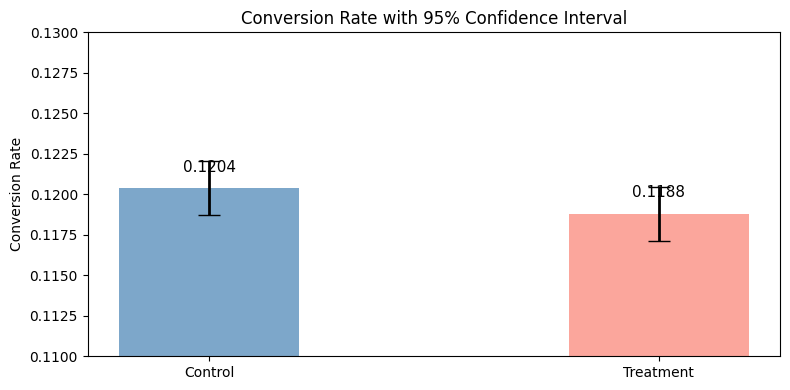

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

groups = ['Control', 'Treatment']
means = [control.mean(), treatment.mean()]
errors_low = [control.mean() - ci_control[0], treatment.mean() - ci_treatment[0]]
errors_high = [ci_control[1] - control.mean(), ci_treatment[1] - treatment.mean()]

ax.bar(groups, means, color=['steelblue', 'salmon'], alpha=0.7, width=0.4)
ax.errorbar(groups, means,
            yerr=[errors_low, errors_high],
            fmt='none', color='black', capsize=8, linewidth=2)

ax.set_ylabel('Conversion Rate')
ax.set_title('Conversion Rate with 95% Confidence Interval')
ax.set_ylim(0.11, 0.13)

for i, (g, m) in enumerate(zip(groups, means)):
    ax.text(i, m + 0.001, f'{m:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../figures/conversion_rate_ci.png', dpi=150)
plt.show()